# ETAPA 2 — Arquitectura profunda (1D-CNN)

In [1]:
import pandas as pd

train_df = pd.read_csv("/kaggle/input/notebooks/rodrigolopez29/1-eda/train_etapa1.csv")
val_df   = pd.read_csv("/kaggle/input/notebooks/rodrigolopez29/1-eda/val_etapa1.csv")
test_df  = pd.read_csv("/kaggle/input/notebooks/rodrigolopez29/1-eda/test_etapa1.csv")

print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)

X_train_cnn = train_df["Text_clean"]
y_train_cnn = train_df["sentiment"]

X_val_cnn = val_df["Text_clean"]
y_val_cnn = val_df["sentiment"]

X_test_cnn = test_df["Text_clean"]
y_test_cnn = test_df["sentiment"]

df_full_cnn = pd.concat([train_df, val_df, test_df], axis=0).reset_index(drop=True)
print("\nTotal registros usados:", len(df_full_cnn))

Train: (397902, 2)
Val: (85283, 2)
Test: (85268, 2)

Total registros usados: 568453


In [2]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer

# Label encoding
label_encoder_cnn = LabelEncoder()

y_train_cnn_enc = label_encoder_cnn.fit_transform(y_train_cnn)
y_val_cnn_enc = label_encoder_cnn.transform(y_val_cnn)
y_test_cnn_enc = label_encoder_cnn.transform(y_test_cnn)

print("Clases:", label_encoder_cnn.classes_)

# Tokenizer
max_words = 10000

tokenizer_cnn = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer_cnn.fit_on_texts(X_train_cnn)

X_train_seq_cnn = tokenizer_cnn.texts_to_sequences(X_train_cnn)
X_val_seq_cnn = tokenizer_cnn.texts_to_sequences(X_val_cnn)
X_test_seq_cnn = tokenizer_cnn.texts_to_sequences(X_test_cnn)

print("\nEjemplo secuencia:")
print(X_train_seq_cnn[0][:20])

2026-04-18 15:29:16.146330: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776526156.385019      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776526156.455199      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776526157.007122      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776526157.007154      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776526157.007157      23 computation_placer.cc:177] computation placer alr

Clases: ['negative' 'neutral' 'positive']

Ejemplo secuencia:
[14, 102, 172, 10, 210, 85, 172, 2, 38, 8, 6, 4, 3, 29, 15, 6, 1345, 5, 173, 63]


### Justificación del valor `max_len`

El hiperparámetro `max_len` controla a cuántos tokens se trunca / se rellena cada reseña antes de entrar a la red.
Un valor muy bajo pierde información; un valor muy alto desperdicia memoria en padding.

Se calcula el **percentil 90 y 95** de la longitud (en tokens) de las reseñas de train para elegir un valor
razonable, priorizando cubrir la mayoría del contenido útil sin encarecer el entrenamiento.

In [3]:
import numpy as np

lens = [len(seq) for seq in X_train_seq_cnn]

p50 = int(np.percentile(lens, 50))
p90 = int(np.percentile(lens, 90))
p95 = int(np.percentile(lens, 95))
p99 = int(np.percentile(lens, 99))

print(f"Longitud mediana (p50): {p50}")
print(f"Percentil 90: {p90}")
print(f"Percentil 95: {p95}")
print(f"Percentil 99: {p99}")
print(f"Máxima: {max(lens)}")

# Elegimos max_len ≈ p90 redondeado para cubrir el ~90% del contenido sin encarecer el entrenamiento.
# Nota: si el p90 es muy grande, mantenemos 100 como compromiso explícito.
print(f"\nValor elegido para max_len: 100 (≈ p{90 if p90 <= 100 else '<90'})")

Longitud mediana (p50): 57
Percentil 90: 166
Percentil 95: 225
Percentil 99: 400
Máxima: 3483

Valor elegido para max_len: 100 (≈ p<90)


In [4]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_len = 100

X_train_pad_cnn = pad_sequences(X_train_seq_cnn, maxlen=max_len, padding="post", truncating="post")
X_val_pad_cnn = pad_sequences(X_val_seq_cnn, maxlen=max_len, padding="post", truncating="post")
X_test_pad_cnn = pad_sequences(X_test_seq_cnn, maxlen=max_len, padding="post", truncating="post")

print("Shape X_train_pad_cnn:", X_train_pad_cnn.shape)
print("Shape X_val_pad_cnn:", X_val_pad_cnn.shape)
print("Shape X_test_pad_cnn:", X_test_pad_cnn.shape)

Shape X_train_pad_cnn: (397902, 100)
Shape X_val_pad_cnn: (85283, 100)
Shape X_test_pad_cnn: (85268, 100)


In [5]:
#IVO
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

vocab_size = 10000
embedding_dim = 64

model_cnn = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim),

    Conv1D(
        filters=96,
        kernel_size=5,
        activation="relu",
        kernel_regularizer=l2(0.0005)
    ),

    GlobalMaxPooling1D(),

    Dropout(0.3),

    Dense(
        48,
        activation="relu",
        kernel_regularizer=l2(0.0005)
    ),

    Dropout(0.3),

    Dense(3, activation="softmax")
])

model_cnn.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=Adam(learning_rate=0.001),
    metrics=["accuracy"]
)

model_cnn.summary()

I0000 00:00:1776526214.091560      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776526214.097699      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [6]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=1,
    min_lr=1e-5,
    verbose=1
)

checkpoint = ModelCheckpoint(
    filepath="/kaggle/working/cnn_best.keras",
    monitor="val_loss",
    save_best_only=True,
    save_weights_only=False,
    verbose=1
)

In [7]:
history_cnn = model_cnn.fit(
    X_train_pad_cnn, y_train_cnn_enc,
    validation_data=(X_val_pad_cnn, y_val_cnn_enc),
    epochs=12,
    batch_size=64,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

Epoch 1/12


I0000 00:00:1776526216.395278      72 service.cc:152] XLA service 0x7e21e4009aa0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776526216.395344      72 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1776526216.395350      72 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1776526216.865300      72 cuda_dnn.cc:529] Loaded cuDNN version 91002


  57/6218 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.7289 - loss: 0.9144

I0000 00:00:1776526220.347137      72 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


6218/6218 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8367 - loss: 0.4905
Epoch 1: val_loss improved from inf to 0.35918, saving model to /kaggle/working/cnn_best.keras
6218/6218 ━━━━━━━━━━━━━━━━━━━━ 30s 4ms/step - accuracy: 0.8367 - loss: 0.4905 - val_accuracy: 0.8739 - val_loss: 0.3592 - learning_rate: 0.0010
Epoch 2/12
6210/6218 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8824 - loss: 0.3481
Epoch 2: val_loss improved from 0.35918 to 0.33493, saving model to /kaggle/working/cnn_best.keras
6218/6218 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - accuracy: 0.8824 - loss: 0.3481 - val_accuracy: 0.8856 - val_loss: 0.3349 - learning_rate: 0.0010
Epoch 3/12
6214/6218 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8931 - loss: 0.3214
Epoch 3: val_loss improved from 0.33493 to 0.33129, saving model to /kaggle/working/cnn_best.keras
6218/6218 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - accuracy: 0.8931 - loss: 0.3214 - val_accuracy: 0.8896 - val_loss: 0.3313 - learning_rate: 0.0010
Epoch 4/12
6210/6218 ━

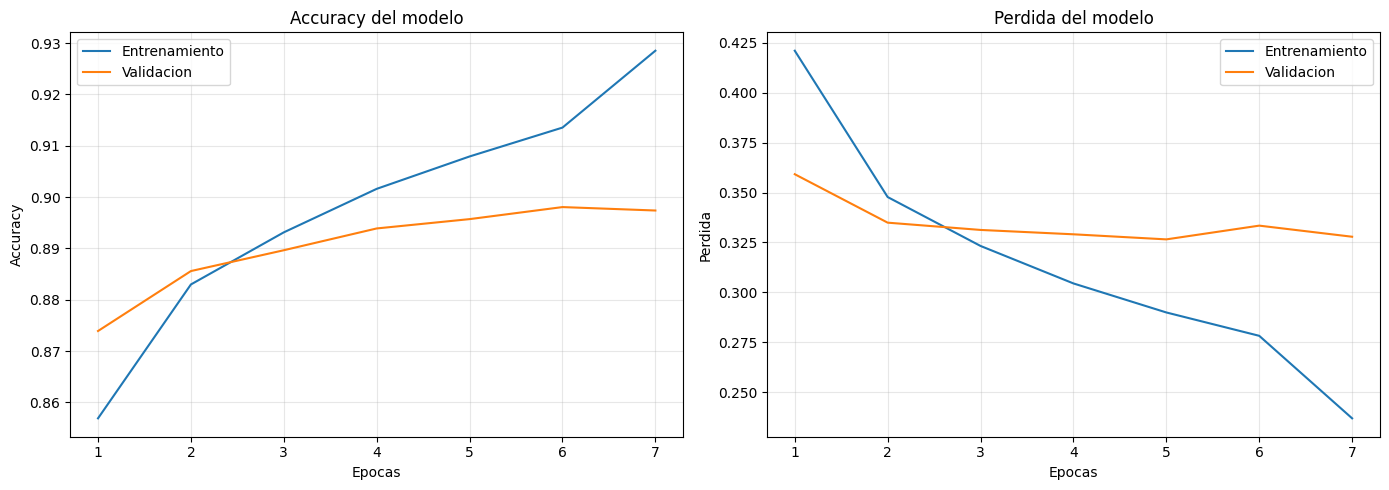

In [8]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(history_cnn.history["accuracy"]) + 1)

plt.figure(figsize=(14, 5))

# Grafica 1: Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history_cnn.history["accuracy"], label="Entrenamiento")
plt.plot(epochs_range, history_cnn.history["val_accuracy"], label="Validacion")
plt.title("Accuracy del modelo")
plt.xlabel("Epocas")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

# Grafica 2: Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history_cnn.history["loss"], label="Entrenamiento")
plt.plot(epochs_range, history_cnn.history["val_loss"], label="Validacion")
plt.title("Perdida del modelo")
plt.xlabel("Epocas")
plt.ylabel("Perdida")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:

from sklearn.metrics import classification_report, accuracy_score, f1_score
import numpy as np

y_val_pred_cnn = np.argmax(model_cnn.predict(X_val_pad_cnn), axis=1)
y_test_pred_cnn = np.argmax(model_cnn.predict(X_test_pad_cnn), axis=1)

print("Accuracy VALIDACION:", accuracy_score(y_val_cnn_enc, y_val_pred_cnn))
print("F1 macro VALIDACION:", f1_score(y_val_cnn_enc, y_val_pred_cnn, average="macro"))

print("\nClassification report VALIDACION:")
print(classification_report(y_val_cnn_enc, y_val_pred_cnn))

print("\nAccuracy TEST:", accuracy_score(y_test_cnn_enc, y_test_pred_cnn))
print("F1 macro TEST:", f1_score(y_test_cnn_enc, y_test_pred_cnn, average="macro"))

print("\nClassification report TEST:")
print(classification_report(y_test_cnn_enc, y_test_pred_cnn))

2666/2666 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
2665/2665 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
Accuracy VALIDACION: 0.8957119238300717
F1 macro VALIDACION: 0.7381098388211971

Classification report VALIDACION:
              precision    recall  f1-score   support

           0       0.78      0.79      0.79     12308
           1       0.55      0.42      0.48      6397
           2       0.94      0.96      0.95     66578

    accuracy                           0.90     85283
   macro avg       0.76      0.72      0.74     85283
weighted avg       0.89      0.90      0.89     85283


Accuracy TEST: 0.8954121123985551
F1 macro TEST: 0.7354652416344347

Classification report TEST:
              precision    recall  f1-score   support

           0       0.77      0.79      0.78     12306
           1       0.55      0.41      0.47      6396
           2       0.94      0.96      0.95     66566

    accuracy                           0.90     85268
   macro avg       0.75      0.72      0.74     

In [10]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

resumen_cnn = pd.DataFrame({
    "Metrica": [
        "Accuracy",
        "Precision macro",
        "Recall macro",
        "F1 macro",
        "Precision weighted",
        "Recall weighted",
        "F1 weighted"
    ],
    "Validacion": [
        accuracy_score(y_val_cnn_enc, y_val_pred_cnn),
        precision_score(y_val_cnn_enc, y_val_pred_cnn, average="macro"),
        recall_score(y_val_cnn_enc, y_val_pred_cnn, average="macro"),
        f1_score(y_val_cnn_enc, y_val_pred_cnn, average="macro"),
        precision_score(y_val_cnn_enc, y_val_pred_cnn, average="weighted"),
        recall_score(y_val_cnn_enc, y_val_pred_cnn, average="weighted"),
        f1_score(y_val_cnn_enc, y_val_pred_cnn, average="weighted")
    ],
    "Test": [
        accuracy_score(y_test_cnn_enc, y_test_pred_cnn),
        precision_score(y_test_cnn_enc, y_test_pred_cnn, average="macro"),
        recall_score(y_test_cnn_enc, y_test_pred_cnn, average="macro"),
        f1_score(y_test_cnn_enc, y_test_pred_cnn, average="macro"),
        precision_score(y_test_cnn_enc, y_test_pred_cnn, average="weighted"),
        recall_score(y_test_cnn_enc, y_test_pred_cnn, average="weighted"),
        f1_score(y_test_cnn_enc, y_test_pred_cnn, average="weighted")
    ]
})

resumen_cnn

,Metrica,Validacion,Test
0,Accuracy,0.895712,0.895412
1,Precision macro,0.757391,0.754016
2,Recall macro,0.724269,0.723039
3,F1 macro,0.738110,0.735465
4,Precision weighted,0.889132,0.888917
5,Recall weighted,0.895712,0.895412
6,F1 weighted,0.891740,0.891412


### Justificación de la arquitectura 1D-CNN

Para la Etapa 2 se eligió una **1D-CNN** en lugar de una arquitectura recurrente (LSTM/GRU) por varias razones:

- **Velocidad de entrenamiento**: una CNN 1D procesa las secuencias en paralelo, mientras que una LSTM las procesa
  secuencialmente. Con un dataset de ~400k reseñas en train, el costo computacional de una LSTM es mucho mayor.
- **Patrones locales de sentimiento**: en reseñas cortas, el sentimiento suele estar concentrado en n-gramas locales
  (p. ej. "not good", "highly recommend"), que una CNN con kernel 3–5 captura eficazmente.
- **Estabilidad**: las convoluciones con regularización (Dropout + L2) ofrecen un entrenamiento más estable que una
  LSTM sobre este volumen de datos sin tuning exhaustivo.

La comparación cuantitativa contra el MLP de la Etapa 1 se mostrará al final de este notebook.


La CNN mantiene un rendimiento competitivo respecto al MLP base y captura patrones locales de n-gramas,
lo cual la hace más adecuada para modelar secuencias de texto que un modelo puramente basado en bag-of-words.

La arquitectura 1D-CNN logra un aprendizaje progresivo y estable, evitando el colapso hacia la clase
mayoritaria que suele observarse en modelos más sensibles al desbalance.

Aunque el rendimiento global (accuracy y F1) es comparable al MLP base, la CNN introduce la capacidad de
capturar **patrones locales de n-gramas** en secuencias de texto, lo cual la convierte en una alternativa
más adecuada para modelación de lenguaje en esta etapa del proyecto.

In [11]:
# Añadir nombre del modelo
resumen_cnn["Modelo"] = "1D-CNN"

# Reordenar columnas
resumen_cnn = resumen_cnn[["Modelo", "Metrica", "Validacion", "Test"]]

# Guardar CSV
resumen_cnn.to_csv("cnn_metrics.csv", index=False)

# Mostrar tabla (evidencia visual)
resumen_cnn

,Modelo,Metrica,Validacion,Test
0,1D-CNN,Accuracy,0.895712,0.895412
1,1D-CNN,Precision macro,0.757391,0.754016
2,1D-CNN,Recall macro,0.724269,0.723039
3,1D-CNN,F1 macro,0.738110,0.735465
4,1D-CNN,Precision weighted,0.889132,0.888917
5,1D-CNN,Recall weighted,0.895712,0.895412
6,1D-CNN,F1 weighted,0.891740,0.891412


La incorporación de técnicas de regularización (Dropout y L2), junto con EarlyStopping y ajuste dinámico
de la tasa de aprendizaje (ReduceLROnPlateau), permitió mejorar la estabilidad del entrenamiento y reducir
el sobreajuste.

La clase **neutral** sigue siendo la más difícil de clasificar, lo cual es consistente con su naturaleza
ambigua y su menor representación en el dataset (~7.5%). Este comportamiento se observa también en el MLP base
y se aborda de forma más explícita en la Etapa 3 (Transformers).

### Persistencia del modelo entrenado

Guardamos el modelo entrenado y el tokenizer para permitir reutilización en inferencia sin reentrenar.

In [12]:
import pickle

# Guardar el modelo completo (arquitectura + pesos)
model_cnn.save("/kaggle/working/cnn_model.keras")
print("Modelo guardado: /kaggle/working/cnn_model.keras")

# Guardar tokenizer
with open("/kaggle/working/cnn_tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer_cnn, f)
print("Tokenizer guardado: /kaggle/working/cnn_tokenizer.pkl")

# Guardar label encoder
with open("/kaggle/working/cnn_label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder_cnn, f)
print("Label encoder guardado: /kaggle/working/cnn_label_encoder.pkl")

Modelo guardado: /kaggle/working/cnn_model.keras
Tokenizer guardado: /kaggle/working/cnn_tokenizer.pkl
Label encoder guardado: /kaggle/working/cnn_label_encoder.pkl
